In [3]:
import numpy as np
import pandas as pd
import os
import math
import re
import random
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score


In [4]:
#collect data - metadata
data = []
data_dir = "20_newsgroups"
classes = os.listdir(data_dir)
for folder in classes:
    folder_path = f"{data_dir}/{folder}"
    if(os.path.exists(folder_path)):
        files = os.listdir(folder_path)
        print(len(files), folder_path)
        for file in files:
            file_path = f"{folder_path}/{file}"
            with open(file_path, "r", encoding="utf-8", errors="ignore" ) as f:
                text = f.read()
                data.append({"label": folder, "text": text})

1000 20_newsgroups/rec.motorcycles
1000 20_newsgroups/comp.sys.ibm.pc.hardware
1000 20_newsgroups/comp.windows.x
1000 20_newsgroups/comp.os.ms-windows.misc
1000 20_newsgroups/rec.sport.baseball
1000 20_newsgroups/sci.electronics
1000 20_newsgroups/misc.forsale
1000 20_newsgroups/sci.crypt
1000 20_newsgroups/comp.graphics
1000 20_newsgroups/sci.med
1000 20_newsgroups/alt.atheism
1000 20_newsgroups/talk.politics.guns
1000 20_newsgroups/sci.space
1000 20_newsgroups/talk.politics.misc
1000 20_newsgroups/talk.politics.mideast
1000 20_newsgroups/rec.autos
1000 20_newsgroups/rec.sport.hockey
997 20_newsgroups/soc.religion.christian
1000 20_newsgroups/comp.sys.mac.hardware
1000 20_newsgroups/talk.religion.misc


In [5]:
## feature engineering - clean data
def clean_text(data):
    if not data:
        return []
    data = data.lower()
    data = re.sub(r'[^\w\s]', ' ', data)
    data = re.sub(r'\d+', ' ', data)
    data = re.sub(r'\s+', ' ', data).strip()
    token = data.split()
    token = [t for t in token if len(t) > 2]
    return token

#Count terms frequency for each document
def term_frequency(data):
    dictionary = dict.fromkeys(set(data), 0)
    for token in data:
        dictionary[token] +=1
    return dictionary

for data_point in data:
    tokens = clean_text(data_point["text"])
    data_point["token_data"] = tokens
    data_point["term_freq_dict"] = term_frequency(tokens)


In [6]:
def fit(data,classes):
    vocab_global = set()
    class_word_counts = {}     
    class_word_freqs = {} 
    priors = {}                
    cond_probs = {}
    total_docs = len(data)

    for clas in classes:
        class_word_counts[clas] = 0
        class_word_freqs[clas] = {}
        priors[clas] = 0
    for d in data:
        class_label = d["label"]
        priors[class_label] += 1

        for term, freq in d["term_freq_dict"].items():
            class_word_freqs[class_label][term] = class_word_freqs[class_label].get(term, 0) + freq
            vocab_global.add(term)
            class_word_counts[class_label] += freq

    for clas in classes:
        priors[clas] = priors[clas] / total_docs

    total_vocab = len(vocab_global)

    for clas in classes:
        total_words_in_class = class_word_counts[clas]
        cond_probs[clas]={}
        for word in vocab_global:
            count_word_count = class_word_freqs[clas].get(word,0)
            cond_probs[clas][word] = (count_word_count + 1) / (total_words_in_class + total_vocab)

    return {
        "prior_probs": priors,
        "cond_probs": cond_probs,
        "vocabulary": vocab_global,
        "class_word_counts": class_word_counts
    }

In [7]:
def predict(doc, model):
    """
    Predict - P(Class)
    doc - dict {word: count}
    """
    priors = model["prior_probs"]
    cond_probs = model["cond_probs"]
    vocab = model["vocabulary"]

    probablity = {}

    for clas in priors:
        if priors[clas] <= 0:
            class_c = float("-inf")
        else:
            class_c = math.log(priors[clas])
        
        for word, count in doc.items():
            if word in vocab:
                prob_w_c = cond_probs[clas].get(word,0)
                if prob_w_c > 0:
                    class_c += count * math.log(prob_w_c)
        probablity[clas] = class_c

    prediction = max(probablity, key=probablity.get)
    return prediction, probablity

In [8]:
random.shuffle(data)

label_groups = {}
for d in data:
    label = d["label"]
    label_groups.setdefault(label, []).append(d)

train_data, test_data = [], []

for label, items in label_groups.items():
    n_total = len(items)
    n_test = int(n_total * 0.5)
    test_data.extend(items[:n_test])
    train_data.extend(items[n_test:])

In [9]:
model = fit(train_data, classes)

In [10]:
confusion_matrix = np.zeros((20,20),dtype=int)
total_accuracy = 0
for doc in test_data:
    prediction, prediction_classes = predict(doc["term_freq_dict"],model)
    i = classes.index(prediction)
    j = classes.index(doc["label"]) 
    confusion_matrix[i][j] +=1
    if (doc["label"] == prediction):
        total_accuracy+=1
print("Accuracy: ",total_accuracy / len(test_data))




Accuracy:  0.8890778155631126


In [13]:
y_true = []
y_pred = []

for doc in test_data:
    prediction, _ = predict(doc["term_freq_dict"], model)
    
    y_true.append(doc["label"])
    y_pred.append(prediction)

print("Macro F1:", f1_score(y_true, y_pred, average='macro'))
print("Micro F1:", f1_score(y_true, y_pred, average='micro'))

print("Macro Precision:", precision_score(y_true, y_pred, average='macro'))
print("Macro Recall:", recall_score(y_true, y_pred, average='macro'))

print("\nClassification Report:\n")
report = classification_report(y_true, y_pred, output_dict=True)

for class_name in classes:
    print(
        f"{class_name}: "
        f"Precision={report[class_name]['precision']:.3f}, "
        f"Recall={report[class_name]['recall']:.3f}, "
        f"F1={report[class_name]['f1-score']:.3f}"
    )

Macro F1: 0.8888337126303666
Micro F1: 0.8890778155631126
Macro Precision: 0.8900626026462971
Macro Recall: 0.8890995983935742

Classification Report:

rec.motorcycles: Precision=0.975, Recall=0.954, F1=0.965
comp.sys.ibm.pc.hardware: Precision=0.778, Recall=0.840, F1=0.808
comp.windows.x: Precision=0.878, Recall=0.876, F1=0.877
comp.os.ms-windows.misc: Precision=0.934, Recall=0.794, F1=0.858
rec.sport.baseball: Precision=0.978, Recall=0.976, F1=0.977
sci.electronics: Precision=0.913, Recall=0.856, F1=0.883
misc.forsale: Precision=0.897, Recall=0.840, F1=0.868
sci.crypt: Precision=0.948, Recall=0.982, F1=0.965
comp.graphics: Precision=0.810, Recall=0.850, F1=0.829
sci.med: Precision=0.985, Recall=0.934, F1=0.959
alt.atheism: Precision=0.839, Recall=0.810, F1=0.824
talk.politics.guns: Precision=0.858, Recall=0.908, F1=0.882
sci.space: Precision=0.920, Recall=0.962, F1=0.940
talk.politics.misc: Precision=0.762, Recall=0.802, F1=0.782
talk.politics.mideast: Precision=0.947, Recall=0.936, 

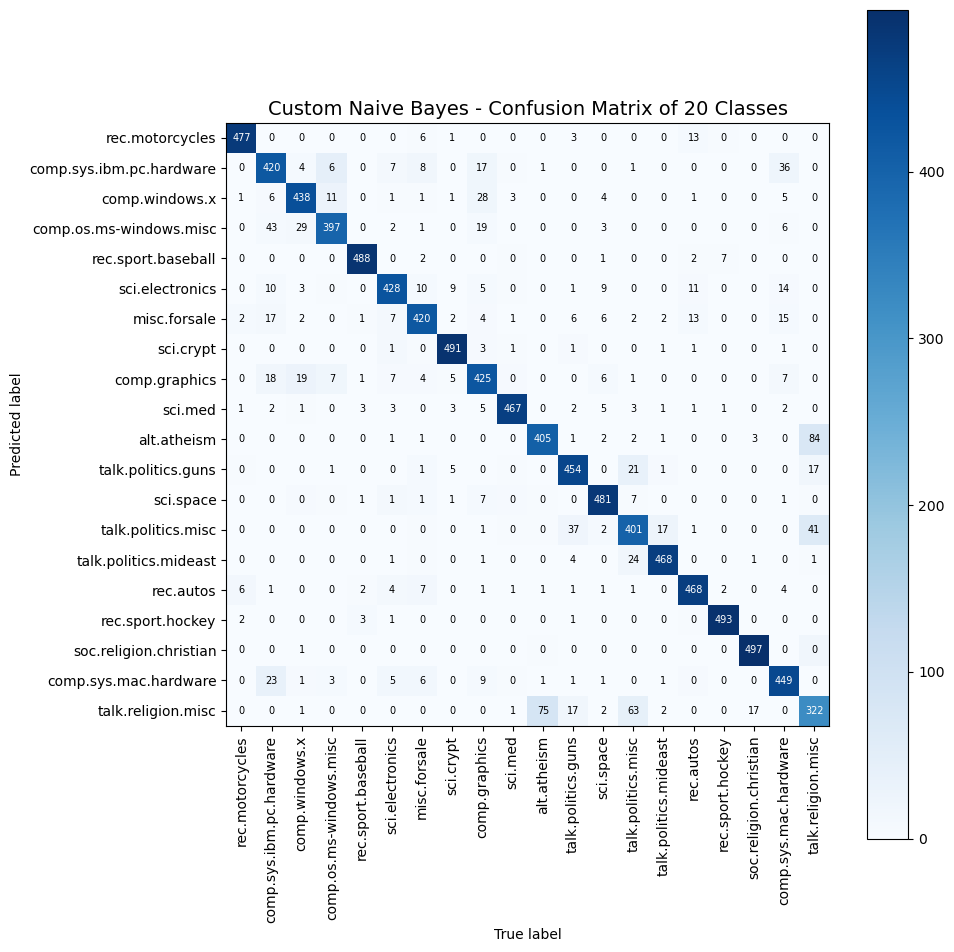

In [12]:
fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(confusion_matrix, interpolation='nearest', cmap='Blues')

ax.set_title("Custom Naive Bayes - Confusion Matrix of 20 Classes", fontsize=14)
fig.colorbar(im, ax=ax)

ax.set_xticks(np.arange(len(classes)))
ax.set_yticks(np.arange(len(classes)))
ax.set_xticklabels(classes, rotation=90)
ax.set_yticklabels(classes)

thresh = confusion_matrix.max() / 2.
for i in range(confusion_matrix.shape[0]):
    for j in range(confusion_matrix.shape[1]):
        ax.text(i, j, f"{confusion_matrix[i, j]:d}",
                ha="center", va="center",
                color="white" if confusion_matrix[i, j] > thresh else "black",
                fontsize=7)

ax.set_ylabel('Predicted label')
ax.set_xlabel('True label')
plt.tight_layout()
plt.show()

In [15]:
cm = confusion_matrix.copy()
np.fill_diagonal(cm, 0)  
most_confused = np.unravel_index(np.argmax(cm), cm.shape)

true_class = classes[most_confused[0]]
pred_class = classes[most_confused[1]]
count = cm[most_confused]

print(f"Most confused pair: {true_class} → {pred_class} ({count} times)")

Most confused pair: talk.religion.misc → alt.atheism (84 times)


In [17]:
examples = []

for doc in test_data:
    prediction, _ = predict(doc["term_freq_dict"], model)
    
    if doc["label"] == true_class and prediction == pred_class:
        examples.append(doc["text"])
    
    if len(examples) == 3:
        break

for i, text in enumerate(examples):
    print(f"\nExample {i+1}:\n")
    print(text[:500])


Example 1:

Xref: cantaloupe.srv.cs.cmu.edu talk.abortion:121413 alt.atheism:54022 talk.religion.misc:84267
Path: cantaloupe.srv.cs.cmu.edu!crabapple.srv.cs.cmu.edu!bb3.andrew.cmu.edu!news.sei.cmu.edu!cis.ohio-state.edu!zaphod.mps.ohio-state.edu!howland.reston.ans.net!agate!netsys!ibmpcug!mantis!news
From: mathew <mathew@mantis.co.uk>
Newsgroups: talk.abortion,alt.atheism,talk.religion.misc
Subject: Re: After 2000 years, can we say that Christian Morality is
Message-ID: <930422.113807.7Q9.rusnews.w165w@mant

Example 2:

Xref: cantaloupe.srv.cs.cmu.edu alt.atheism:54159 talk.religion.misc:84351 talk.abortion:121535
Newsgroups: alt.atheism,talk.religion.misc,talk.abortion
Path: cantaloupe.srv.cs.cmu.edu!das-news.harvard.edu!noc.near.net!howland.reston.ans.net!wupost!uunet!wri!elvis.wri.com!markp
From: markp@elvis.wri.com (Mark Pundurs)
Subject: Re: After 2000 years, can we say that Christian Morality is
Message-ID: <markp.735836823@elvis.wri.com>
Sender: news@wri.com
Nntp-Posting-Host: 